# Tutorial 100: Unconditional Flow Matching on Synthetic Data

In this tutorial, we train a flow matching model to learn a velocity field that maps standard gaussian noise to the two-moons data distribution.

In [ ]:
%load_ext autoreload
%autoreload 2

## Contents

* **Section 1**: Data Creation
* **Section 2**: SCFlow Register Setup
* **Section 3**: Model Setup
* **Section 4**: Training
* **Section 5**: Saving & Loading Data
* **Section 6**: Inference
* **Section 7**: ODE Trajectories

In [ ]:
import numpy as np
import anndata as ad
import torch
import matplotlib.pyplot as plt

from sc_flow import SCFlow
from sc_flow.dataset.toy_data import get_toy_dataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Data Creation

We use the package's `get_toy_dataset` to generate our synthetic data. There are multiple types of dataset which can be created, but here we will use `moons` dataset which is a 2D data consisting of 2 crescent shaped data clusters. The output is an `AnnData` object in which the `.uns['datast_info']` contains all the parameters used to create the dataset & `.obs['Y]` contains the labels.

In [ ]:
dataset = get_toy_dataset("moons", n_samples=10_000, noise=0.1, random_state=SEED)
adata = dataset.adata


print(adata)
print(f"Y:{adata.obsm['Y'].ravel()}")  # Which moon does each point belong to. Either '0' or '1' -> Upper or lower moon
print(f"Dataset Parameters: {adata.uns['dataset_info']}")

AnnData object with n_obs × n_vars = 10000 × 2
    uns: 'dataset_info'
    obsm: 'Y'
Y:['1' '0' '0' ... '1' '0' '1']
Dataset Parameters: {'name': 'moons', 'random_state': 42, 'noise': 0.1, 'shuffle': True}


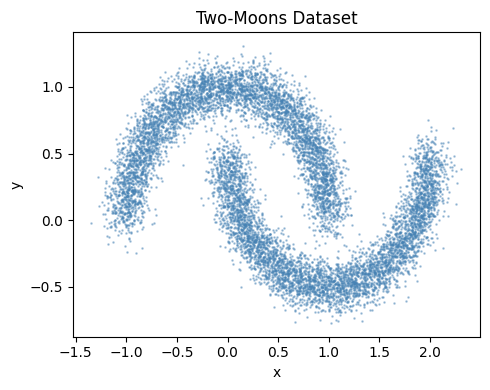

In [ ]:
X = np.array(adata.X)
n = len(X)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], s=0.8, alpha=0.4, color="steelblue")
ax.set_title("Two-Moons Dataset")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Section 2: SCFlow Register Setup

`SCFlow` is the main model class to instantiate, train, predict & save the model. Before creating an SCFlow instance, we have to register the structure of the dataset so that any new SCFlow instances created will already be configured to the dataset. In this tutorial, we will have a simple setup with no extra parameters.

In [ ]:
SCFlow.register_adata(
    adata,
)

In [ ]:
print("state_dim:                   ", SCFlow._dims_registry.state_dim)
print("feature_names:               ", SCFlow._dims_registry.feature_names)
print("condition_reps_dims:         ", SCFlow._dims_registry.condition_reps_dims)
print("condition_continuous_dims:   ", SCFlow._dims_registry.condition_continuous_dims)
print("response_reps_dims:          ", SCFlow._dims_registry.response_reps_dims)
print("response_continuous_dims:    ", SCFlow._dims_registry.response_continuous_dims)
print("groups_reps_dims:            ", SCFlow._dims_registry.groups_reps_dims)
print("source_lin_dim:              ", SCFlow._dims_registry.source_lin_dim)
print("source_quad_dim:             ", SCFlow._dims_registry.source_quad_dim)
print("target_lin_dim:              ", SCFlow._dims_registry.target_lin_dim)
print("target_quad_dim:             ", SCFlow._dims_registry.target_quad_dim)

state_dim:                    2
feature_names:                Index(['0', '1'], dtype='object')
condition_reps_dims:          {}
condition_continuous_dims:    {}
response_reps_dims:           {}
response_continuous_dims:     {}
groups_reps_dims:             {}
source_lin_dim:               2
source_quad_dim:              None
target_lin_dim:               2
target_quad_dim:              None


## Section 3: Model Setup

Now we create an SCFlow model instance. We keep it simple for this tutorial with only the essential parameters.

* `generate_from_noise = True` — tells the model to sample standard Gaussian noise as the source at training time instead of using real source cells. This is the right setting when learning a generative model (noise → data) rather than a transport map (cells → cells).
* `method_id` — tells SCFlow what type of method to use. `cfm` (Conditional Flow Matching) is the general flow matching algorithm provided in this package. If you want to use a custom method class, pass it via `method_cls` instead.
* `backend` — whether to use `torch` or `jax`. Defaults to `torch` if not provided.
* `vf_decoder_mlp_kwargs` — A dict containing parameters to configure the velocity field decoder (the neural network which takes our state, time & conditions and outputs a velocity vector). `hidden_dims` tells `SCFlow` how many hidden layers should be there in this network and what should be it's hidden dimension.

> **Note**: `method_cls` has higher priority than `method_id` if both are given.

In [ ]:
model = SCFlow(
    method_id="cfm",
    backend="torch",
    generate_from_noise=True,
    vf_decoder_mlp_kwargs={
        "hidden_dims": [
            32,
            32,
        ]
    },
)

In [ ]:
print(f"Backend:         {model.backend}")
print(f"DataManager:     {model.dm}")  # The DataManager instance that handles data loading and batching
print(f"Method:          {model.method}")
print(f"Paired Settings: {model.is_paired_setting}")

Backend:         torch
DataManager:     <sc_flow.data._manager.DataManager object at 0x000001BC6D3F42F0>
Method:          <sc_flow.backends.torch.methods.library._cfm.CFM object at 0x000001BC78BF83B0>
Paired Settings: False


## Section 4: Training

Training the model via the SCFlow instance is straight forward. `optim_kwargs` is a dict of parameters used for initializing an optimizer. We pass `lr` which is passed to `Adam`by default.

It creates a `trainer` which holds all the logs for training and validation which can be called as a `pd.DataFrame`.

In [ ]:
model.train(
    adata,
    n_train_steps=10_000,
    train_batch_size=512,
    optim_kwargs={"lr": 1e-4},
)

100%|██████████| 1/1 [00:00<00:00, 1790.91it/s]
| loss:1.0896 | step:10000: 100%|██████████| 10000/10000 [01:24<00:00, 118.10it/s]


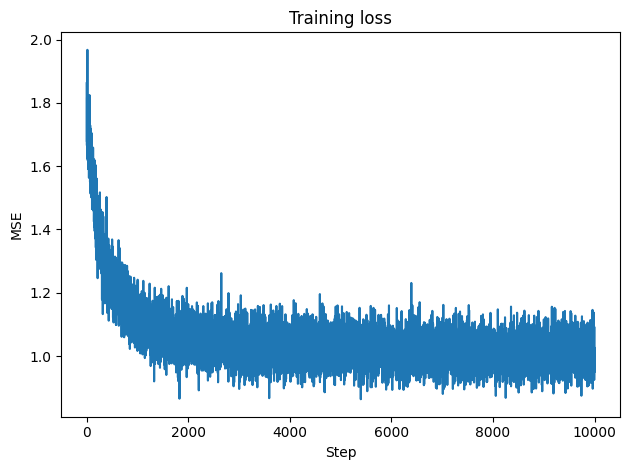

In [ ]:
logs_df = model.trainer.get_train_logs_df()
plt.plot(logs_df.index, logs_df["loss"])
plt.title("Training loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

## Section 5: Saving & Loading model

Before moving onto testing, lets save the model. SCFlow allows you to save the entire model along with the registered data as well.

In [ ]:
model.save(filepath="cfm_moons_model.pt", allow_overwrite=True)

In [ ]:
model = SCFlow.load(filepath="cfm_moons_model.pt")

## Section 6: Testing

To test how well our model maps a source to the two-moons dataset, we create a test dataset which will be gaussian as well ask the model to predict on this unseeen dataset.

In [ ]:
X_all = np.array(adata.X)  # target
X_source = np.random.randn(len(adata), 2).astype(np.float32)  # Gaussian source
adata_source = ad.AnnData(X_source)

adata_pred = model.predict(adata_source)
X_pred = np.array(adata_pred.X)
print(adata_pred)

Predicting: 100%|██████████| 1/1 [00:00<00:00,  1.02it/s]

AnnData object with n_obs × n_vars = 10000 × 2



C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


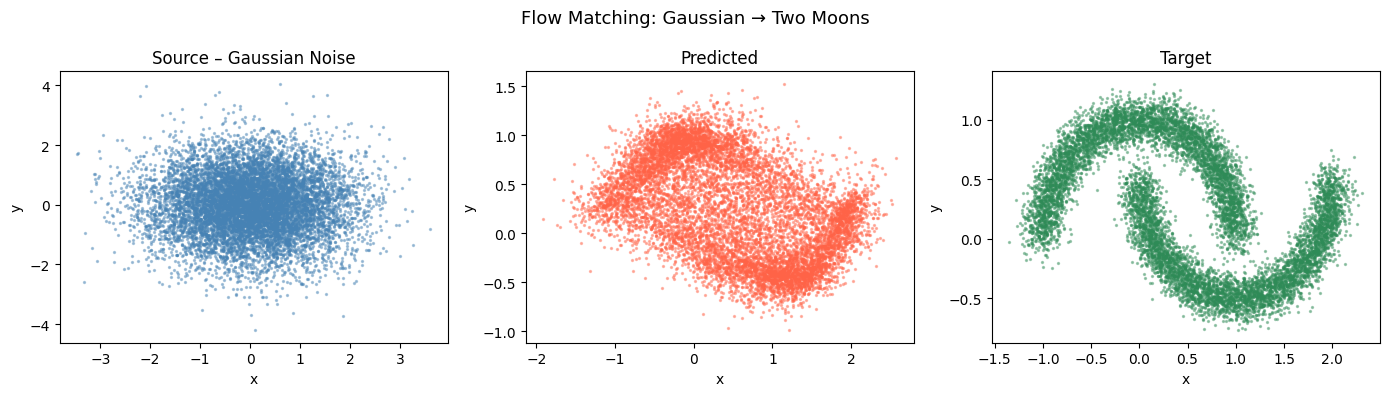

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(X_source[:, 0], X_source[:, 1], s=2, alpha=0.4, color="steelblue")
axes[0].set_title("Source – Gaussian Noise")

axes[1].scatter(X_pred[:, 0], X_pred[:, 1], s=2, alpha=0.4, color="tomato")
axes[1].set_title("Predicted")

axes[2].scatter(X_all[:, 0], X_all[:, 1], s=2, alpha=0.4, color="seagreen")
axes[2].set_title("Target")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Flow Matching: Gaussian → Two Moons", fontsize=13)
plt.tight_layout()
plt.show()

## Section 7: ODE Trajectories

Here we will see what the trajectories that the source points take to move to the two-moons dataset positions look like. Using `return_trajectory=True` and controlling `num_steps`, we can get the trajectory of the predicted source points.

In [ ]:
adata_traj = model.predict(adata_source, return_trajectory=True, num_steps=20)
traj = adata_traj.obsm["trajectory"]  # shape: (n_cells, n_steps, state_dim)
print(f"trajectory shape: {traj.shape}")

Predicting: 100%|██████████| 1/1 [00:00<00:00,  3.63it/s]

trajectory shape: (10000, 20, 2)



C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


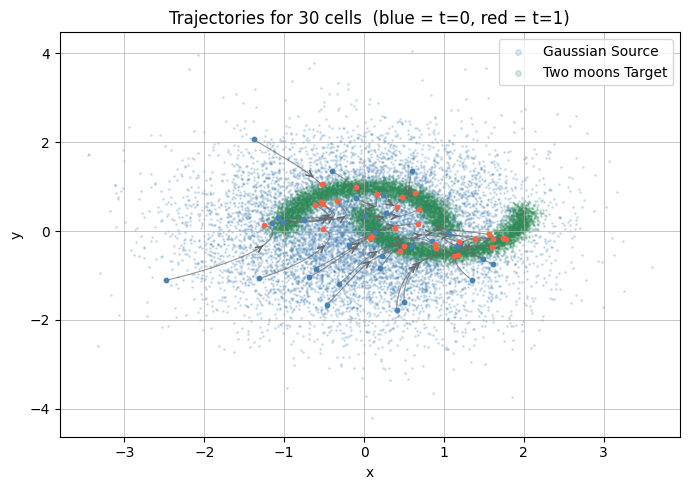

In [ ]:
N_SHOW = 30
idxs = np.random.choice(traj.shape[0], N_SHOW, replace=False)
traj_sub = traj[idxs, :, :]  # (N_SHOW, n_steps, state_dim)

fig, ax = plt.subplots(figsize=(7, 5))

# Plot all the source & target points
ax.scatter(X_source[:, 0], X_source[:, 1], s=1, alpha=0.2, color="steelblue", label="Gaussian Source")
ax.scatter(X_all[:, 0], X_all[:, 1], s=1, alpha=0.2, color="seagreen", label="Two moons Target")


mid = traj_sub.shape[1] // 2
for i in range(N_SHOW):
    ax.plot(traj_sub[i, :, 0], traj_sub[i, :, 1], lw=0.8, alpha=0.7, color="dimgray")  # Plot trajectory
    ax.annotate(
        "",
        xy=(traj_sub[i, mid + 1, 0], traj_sub[i, mid + 1, 1]),
        xytext=(traj_sub[i, mid, 0], traj_sub[i, mid, 1]),
        arrowprops={"arrowstyle": "->", "color": "dimgray", "lw": 1.2},
    )
    # Plot start and end points of the trajectory
    ax.scatter(traj_sub[i, 0, 0], traj_sub[i, 0, 1], s=10, color="steelblue", zorder=5)
    ax.scatter(traj_sub[i, -1, 0], traj_sub[i, -1, 1], s=10, color="tomato", zorder=5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Trajectories for {N_SHOW} cells  (blue = t=0, red = t=1)")
ax.legend(markerscale=4)
ax.grid(linewidth=0.5)
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`110_unconditional_fm_pbmc.ipynb`](110_unconditional_fm_pbmc.ipynb) | The same generative task on PBMC data |
| [`200_conditional_fm_synthetic.ipynb`](200_conditional_fm_synthetic.ipynb) | Conditional FM task on Synthetic data |